Data Cleaning and Visualization Using Python - 3/12/2026 - April Taylor

In [1]:
import pandas as pd
import numpy as np

#Load dataset from excel
df = pd.read_excel(r"C:\Files\Excel\DA_Excel\AirBnBSummary_v2.xlsx", sheet_name="ListingData")

#Remove duplicates
df = df.drop_duplicates()

#Standardize text based columns (convert them to title case)
text_cols = ['host_name', 'neighbourhood', 'room_type']
for col in text_cols:
    df[col] = df[col].astype(str).str.title()

#Compute median values for all numeric columns and fill in missing values
median_values = df.median(numeric_only=True)
df = df.fillna(median_values)

#Calculate IQR boundaries to find and remove price outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#Keep only listing with prices withing the acceptable range
df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)]

#Export cleaned dataset to new excel file
df_clean.to_excel("Cleaned_Airbnb.xlsx", index=False)

In [2]:
from scipy import stats

#Count total number of cleaned listings
total_listings = df_clean.shape[0]

#Basic price statistics
min_price = df_clean['price'].min()
max_price = df_clean['price'].max()
mean_price = df_clean['price'].mean()

#Review and minimum-night statistics
median_reviews = df_clean['number_of_reviews'].median()
mode_min_nights = stats.mode(df_clean['minimum_nights'], keepdims=True)[0][0]

#Price variability
std_price = df_clean['price'].std()

#Relationship between price and the yearly availability
correlation = df_clean['price'].corr(df_clean['availability_365'])

#Store all statistics for easy display/export
stats_summary = {
    "Total Listings": int(total_listings),
    "Min Price": float(min_price),
    "Max Price": float(max_price),
    "Mean Price": float(mean_price),
    "Median Reviews": float(median_reviews),
    "Mode Minimum Nights": int(mode_min_nights),
    "Std Dev Price": float(std_price),
    "Correlation (Price vs Availability)": float(correlation)
}

stats_summary

{'Total Listings': 1657,
 'Min Price': 20.0,
 'Max Price': 308.0,
 'Mean Price': 124.13277006638504,
 'Median Reviews': 20.0,
 'Mode Minimum Nights': 1,
 'Std Dev Price': 61.496773365856114,
 'Correlation (Price vs Availability)': 0.10641814057508972}

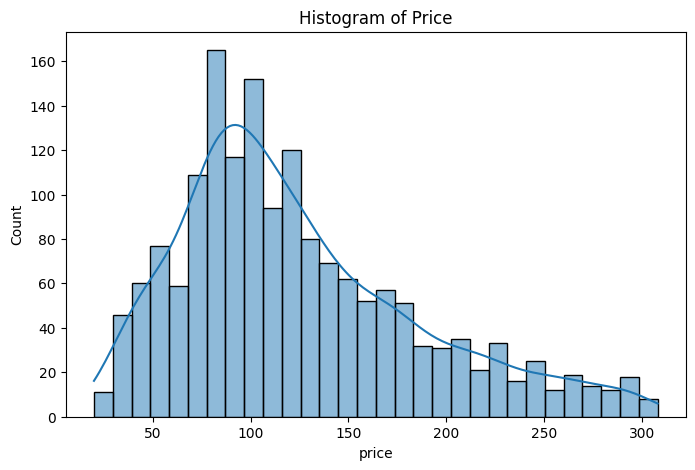

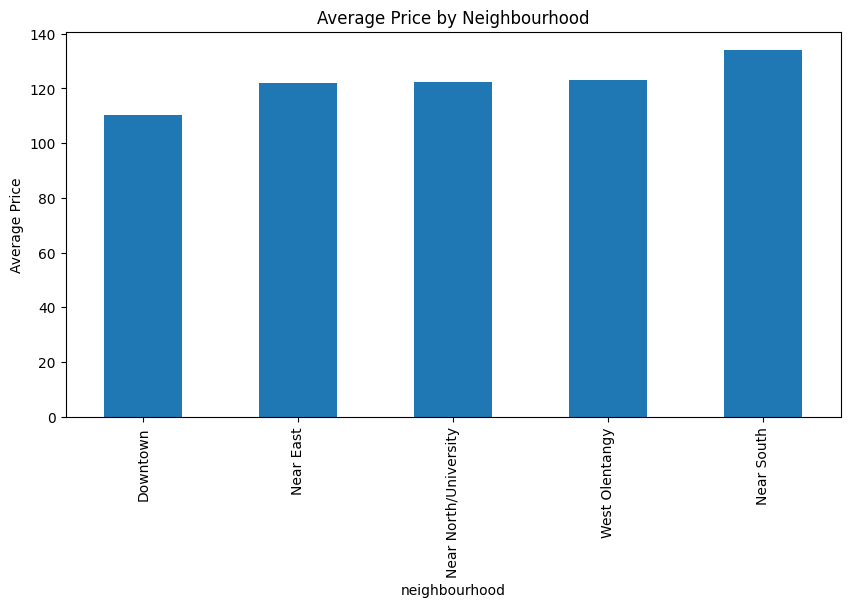

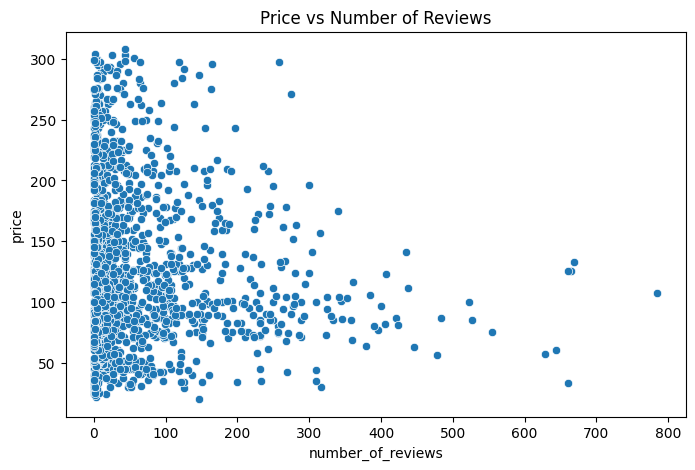

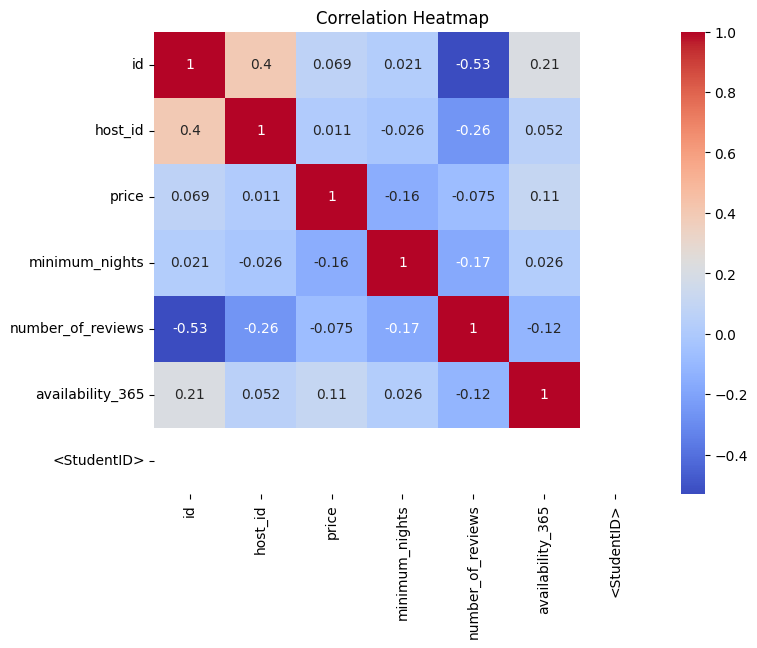

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

#Historgram of listing prices to show overall price distribution
plt.figure(figsize=(8,5))
sns.histplot(df_clean['price'], bins=30, kde=True)
plt.title("Histogram of Price")
plt.show()

#Bar chart showing average price by neighbourhood
plt.figure(figsize=(10,5))
df_clean.groupby('neighbourhood')['price'].mean().sort_values().plot(kind='bar')
plt.title("Average Price by Neighbourhood")
plt.ylabel("Average Price")
plt.show()

#Scatterplot to examine relationship between number of reviews and price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='number_of_reviews', y='price')
plt.title("Price vs Number of Reviews")
plt.show()

#Heatmap to visualize correlations among all numeric variables
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()